# MeAJOR Semantic Hashing (SimHash + kNN)

This notebook implements a Semantic Hashing baseline using SimHash fingerprints derived from TF-IDF
vectors, evaluated on the MeAJOR AI-generated vs. human-written phishing email dataset.

The pipeline follows three stages:
1. TF-IDF vectorisation of preprocessed email text
2. SimHash – generating fixed-length binary fingerprints from TF-IDF weights
3. k-Nearest Neighbour (kNN) classification using Hamming distance between fingerprints

This approach is evaluated using the same metrics schema as all other models in this project
(Accuracy, Precision, Recall, F1, FPR, Inference Time) for direct cross-model comparison.

> **Why SimHash?** SimHash is a locality-sensitive hashing (LSH) technique originally developed
> for near-duplicate web page detection. Applied to email text, it compresses a sparse TF-IDF
> vector into a compact binary fingerprint while preserving semantic similarity – documents with
> similar content produce fingerprints with low Hamming distance. This makes it a computationally
> lightweight alternative to dense embeddings or neural classifiers.

## 1. Import Libraries

All libraries needed for loading data, text preprocessing, TF-IDF vectorisation, SimHash
fingerprint generation, kNN classification, and evaluation are imported here.

In [1]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## 2. Reproducibility and Configuration

A fixed random seed is set to ensure reproducibility. All key hyperparameters and file paths
are defined here in one place.

**TF-IDF choices:**
- `max_features=10000`: Caps vocabulary size to the 10,000 most frequent terms to balance
  representational richness with computational efficiency. Higher values were tested but yielded
  diminishing returns on validation performance.
- `ngram_range=(1, 2)`: Includes unigrams and bigrams to capture short phishing-indicative
  phrases (e.g. "verify account", "click here") that single tokens miss.
- `sublinear_tf=True`: Applies log-normalisation to term frequencies, reducing the dominance
  of very common terms.

**SimHash choices:**
- Hash bit lengths of 64 and 128 are tested. 128-bit provides finer-grained discrimination
  between similar documents; 64-bit is faster. Results for both are reported.

**kNN choices:**
- k values of 1, 3, 5, 7, and 9 are tested. The best-performing k is used for final evaluation.

In [2]:
SEED = 42

# File paths
data_dir    = Path("../data/processed/meajor/")
results_dir = Path("../results/")
results_dir.mkdir(parents=True, exist_ok=True)

# TF-IDF hyperparameters
TFIDF_MAX_FEATURES = 10000
TFIDF_NGRAM_RANGE  = (1, 2)
TFIDF_SUBLINEAR_TF = True

# SimHash hyperparameters
HASH_BITS_OPTIONS = [64, 128]   # Both are evaluated; best is used for final metrics

# kNN hyperparameters
KNN_K_OPTIONS = [1, 3, 5, 7, 9]  # All tested; best k reported

print("Configuration loaded.")
print(f"  TF-IDF max features : {TFIDF_MAX_FEATURES}")
print(f"  TF-IDF n-gram range : {TFIDF_NGRAM_RANGE}")
print(f"  SimHash bit lengths : {HASH_BITS_OPTIONS}")
print(f"  kNN k values        : {KNN_K_OPTIONS}")

Configuration loaded.
  TF-IDF max features : 10000
  TF-IDF n-gram range : (1, 2)
  SimHash bit lengths : [64, 128]
  kNN k values        : [1, 3, 5, 7, 9]


## 3. Load Processed Data

The train and test Parquet files produced by `meajor_preparation.ipynb` are loaded here.
These contain the cleaned `text` and `label` columns.

In [3]:
train_df = pd.read_parquet(data_dir / "meajor_train_60.parquet")
test_df  = pd.read_parquet(data_dir / "meajor_test_40.parquet")

print(f"Train size : {len(train_df)} rows")
print(f"Test size  : {len(test_df)} rows")
print(f"Columns    : {train_df.columns.tolist()}")

Train size : 62743 rows
Test size  : 41829 rows
Columns    : ['text', 'label']


## 4. Verify Loaded Data

A quick check of label distributions and a sample of the text field to confirm the data
loaded correctly before applying TF-IDF.

In [4]:
print("Train label distribution:")
print(train_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

train_df[["text", "label"]].head(3)

Train label distribution:
label
0    34768
1    27975
Name: count, dtype: int64

Test label distribution:
label
0    23179
1    18650
Name: count, dtype: int64


,text,label
0,Subject: OVER [FINANCIAL_INFO] Body: HAS ANY O...,0
1,Subject: Or each ellenton Body: THE ALERT IS O...,1
2,Subject: Best place to find cure for your dise...,1


## 5. Text Preprocessing

Although the preparation notebook already lowercases and strips punctuation, an additional
cleaning step is applied here to:
- Remove any residual HTML tags (phishing emails frequently contain HTML markup)
- Strip stopwords to reduce noise in TF-IDF weights

Stopword removal is applied at this stage (rather than in the preparation notebook) because
it is specific to the TF-IDF+SimHash pipeline – other models (e.g. BiLSTM) benefit from
retaining stopwords for sequential context.

In [5]:
# Minimal stopword list – covers the most frequent English function words
# A full NLTK stopwords list can be substituted if available
STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "by", "from", "is", "was", "are", "were", "be", "been",
    "being", "have", "has", "had", "do", "does", "did", "will", "would",
    "could", "should", "may", "might", "shall", "can", "need", "that",
    "this", "these", "those", "it", "its", "i", "you", "he", "she", "we",
    "they", "my", "your", "his", "her", "our", "their", "me", "him", "us",
    "them", "not", "no", "so", "if", "as", "up", "out", "about", "into",
    "than", "then", "just", "also", "more", "all", "any", "both", "each",
    "few", "here", "there", "when", "where", "who", "which", "what", "how"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)          # strip HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)          # remove non-alpha chars
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

train_texts  = train_df["text"].apply(clean_text).tolist()
test_texts   = test_df["text"].apply(clean_text).tolist()
train_labels = train_df["label"].values
test_labels  = test_df["label"].values

print(f"Sample cleaned text:\n  {train_texts[0][:200]}")

Sample cleaned text:
  subject over financial info body one used motors rated over financial info handy board go interfacing hb anyone use product product bad idea piggy back two chips parallel say problem motors rate amp c


## 6. TF-IDF Vectorisation

TF-IDF (Term Frequency–Inverse Document Frequency) converts each email into a sparse vector
of weighted term importance scores. The vocabulary and IDF weights are fitted on the training
set only to prevent data leakage – the test set is transformed using the training vocabulary.

The resulting sparse matrix is the input to the SimHash stage.

In [6]:
vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    sublinear_tf=TFIDF_SUBLINEAR_TF
)

# Fit on training data only – no test leakage
train_tfidf = vectorizer.fit_transform(train_texts)
test_tfidf  = vectorizer.transform(test_texts)

print(f"TF-IDF train matrix shape : {train_tfidf.shape}")
print(f"TF-IDF test matrix shape  : {test_tfidf.shape}")
print(f"Vocabulary size           : {len(vectorizer.vocabulary_)}")

TF-IDF train matrix shape : (62743, 10000)
TF-IDF test matrix shape  : (41829, 10000)
Vocabulary size           : 10000


## 7. SimHash Implementation

SimHash converts a sparse TF-IDF vector into a fixed-length binary fingerprint as follows:
1. For each term in the document, its TF-IDF weight is used as a real-valued vote
2. Each term maps to a random projection vector drawn from a standard normal distribution
3. The weighted sum of projection vectors is computed
4. The sign of each component is taken – positive → 1, negative → 0
5. The result is a binary fingerprint of length `n_bits`

Documents with similar TF-IDF content will produce fingerprints with low Hamming distance.

The random projection matrix is seeded for reproducibility and fitted once on the vocabulary
dimension of the training TF-IDF matrix.

In [ ]:
def build_simhash_matrix(tfidf_matrix, n_bits, seed=42):
    """
    Generate SimHash binary fingerprints for a TF-IDF sparse matrix.

    Parameters
    ----------
    tfidf_matrix : sparse matrix, shape (n_docs, vocab_size)
    n_bits       : int – number of bits in the output fingerprint
    seed         : int – random seed for reproducibility

    Returns
    -------
    fingerprints : np.ndarray, shape (n_docs, n_bits), dtype uint8
    """
    rng = np.random.RandomState(seed)
    vocab_size = tfidf_matrix.shape[1]

    # Random projection matrix for SimHash
    # Each bit is defined by a random hyperplane
    projections = rng.randn(vocab_size, n_bits).astype(np.float32)

    # Weighted projection: (n_docs, vocab_size) × (vocab_size, n_bits) → (n_docs, n_bits)
    # Convert to dense before the matrix multiply; this is acceptable at this dataset size
    dense = tfidf_matrix.toarray().astype(np.float32)
    scores = dense @ projections   # shape: (n_docs, n_bits)

    # Binarise: 1 where score > 0, else 0
    fingerprints = (scores > 0).astype(np.uint8)
    return fingerprints


# Generate fingerprints for all bit-length options
train_hashes = {}
test_hashes  = {}

for n_bits in HASH_BITS_OPTIONS:
    print(f"Generating {n_bits}-bit SimHash fingerprints...")
    train_hashes[n_bits] = build_simhash_matrix(train_tfidf, n_bits)
    test_hashes[n_bits]  = build_simhash_matrix(test_tfidf,  n_bits)
    print(f"  Train fingerprint shape : {train_hashes[n_bits].shape}")
    print(f"  Test fingerprint shape  : {test_hashes[n_bits].shape}")

Generating 64-bit SimHash fingerprints...
  Train fingerprint shape : (62743, 64)
  Test fingerprint shape  : (41829, 64)
Generating 128-bit SimHash fingerprints...
  Train fingerprint shape : (62743, 128)
  Test fingerprint shape  : (41829, 128)


## 8. Hamming Distance and kNN Classification

Hamming distance counts the number of bit positions where two fingerprints differ.
It serves as the similarity metric for kNN classification on top of SimHash fingerprints.

`KNeighborsClassifier` with `metric='hamming'` is used directly on the binary fingerprint
arrays. Multiple values of k are tested for each hash bit length. The combination of
(n_bits, k) that achieves the best validation F1 on the training set is selected for
final test evaluation.

A 10% stratified validation split is taken from the training set for k-selection.

In [ ]:
from sklearn.model_selection import train_test_split

# Hold out 10% of the training set for tuning k, while keeping class balance
train_idx, val_idx = train_test_split(
    np.arange(len(train_labels)),
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels
)

print(f"Train subset : {len(train_idx)} samples")
print(f"Val subset   : {len(val_idx)} samples")

best_f1      = -1
best_config  = None
results_grid = []

for n_bits in HASH_BITS_OPTIONS:
    X_tr = train_hashes[n_bits][train_idx]
    y_tr = train_labels[train_idx]
    X_val = train_hashes[n_bits][val_idx]
    y_val = train_labels[val_idx]

    for k in KNN_K_OPTIONS:
        knn = KNeighborsClassifier(n_neighbors=k, metric="hamming", n_jobs=-1)
        knn.fit(X_tr, y_tr)
        preds = knn.predict(X_val)

        f1  = f1_score(y_val, preds, zero_division=0)
        acc = accuracy_score(y_val, preds)
        tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        results_grid.append({
            "n_bits": n_bits, "k": k,
            "val_acc": round(acc, 4), "val_f1": round(f1, 4), "val_fpr": round(fpr, 4)
        })

        if f1 > best_f1:
            best_f1     = f1
            best_config = (n_bits, k)

        print(f"  bits={n_bits:3d}, k={k} → Val Acc={acc:.4f}, Val F1={f1:.4f}, Val FPR={fpr:.4f}")

print(f"\nBest config: bits={best_config[0]}, k={best_config[1]}, Val F1={best_f1:.4f}")

Train subset : 56468 samples
Val subset   : 6275 samples
  bits= 64, k=1 → Val Acc=0.7903, Val F1=0.7682, Val FPR=0.2010
  bits= 64, k=3 → Val Acc=0.7971, Val F1=0.7709, Val FPR=0.1775
  bits= 64, k=5 → Val Acc=0.7973, Val F1=0.7686, Val FPR=0.1688
  bits= 64, k=7 → Val Acc=0.7939, Val F1=0.7627, Val FPR=0.1648
  bits= 64, k=9 → Val Acc=0.7916, Val F1=0.7590, Val FPR=0.1639
  bits=128, k=1 → Val Acc=0.8497, Val F1=0.8344, Val FPR=0.1498
  bits=128, k=3 → Val Acc=0.8521, Val F1=0.8358, Val FPR=0.1412
  bits=128, k=5 → Val Acc=0.8537, Val F1=0.8358, Val FPR=0.1314
  bits=128, k=7 → Val Acc=0.8566, Val F1=0.8377, Val FPR=0.1219
  bits=128, k=9 → Val Acc=0.8582, Val F1=0.8384, Val FPR=0.1150

Best config: bits=128, k=9, Val F1=0.8384


## 9. Grid Search Results Summary

A tabular summary of all (n_bits, k) combinations evaluated on the validation set.
This documents the hyperparameter sensitivity of the SimHash + kNN pipeline.

In [9]:
grid_df = pd.DataFrame(results_grid)
print(grid_df.to_string(index=False))

 n_bits  k  val_acc  val_f1  val_fpr
     64  1   0.7903  0.7682   0.2010
     64  3   0.7971  0.7709   0.1775
     64  5   0.7973  0.7686   0.1688
     64  7   0.7939  0.7627   0.1648
     64  9   0.7916  0.7590   0.1639
    128  1   0.8497  0.8344   0.1498
    128  3   0.8521  0.8358   0.1412
    128  5   0.8537  0.8358   0.1314
    128  7   0.8566  0.8377   0.1219
    128  9   0.8582  0.8384   0.1150


## 10. Final Test Evaluation

The best (n_bits, k) configuration found during validation is retrained on the full
training set and evaluated on the held-out test set. Metrics reported are Accuracy,
Precision, Recall, F1, False Positive Rate, and Inference Time per email – consistent
with the unified evaluation framework used across all models in this project.

**Inference time** is measured as model-only prediction time on the full test set,
divided by the number of test emails (milliseconds per email).

In [ ]:
best_bits, best_k = best_config

# Retrain on the full training set with the selected configuration
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric="hamming", n_jobs=-1)
final_knn.fit(train_hashes[best_bits], train_labels)

# Measure prediction time on the test set
N_RUNS = 3
times  = []
X_test = test_hashes[best_bits]

for _ in range(N_RUNS):
    start = time.perf_counter()
    preds = final_knn.predict(X_test)
    end   = time.perf_counter()
    times.append((end - start) * 1000)

inference_ms = round(np.mean(times) / len(test_labels), 4)

# --- Metrics ---
acc  = accuracy_score(test_labels, preds)
prec = precision_score(test_labels, preds, zero_division=0)
rec  = recall_score(test_labels, preds, zero_division=0)
f1   = f1_score(test_labels, preds, zero_division=0)
tn, fp, fn, tp = confusion_matrix(test_labels, preds).ravel()
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"\n{'='*50}")
print(f"  Final Test Results – SimHash + kNN (MeAJOR)")
print(f"  Config: {best_bits}-bit fingerprint, k={best_k}")
print(f"{'='*50}")
print(f"  Accuracy        : {acc:.4f}")
print(f"  Precision       : {prec:.4f}")
print(f"  Recall          : {rec:.4f}")
print(f"  F1 Score        : {f1:.4f}")
print(f"  False Pos. Rate : {fpr:.4f}")
print(f"  Inference Time  : {inference_ms} ms/email")
print(f"\n{classification_report(test_labels, preds, target_names=['Legitimate', 'Phishing'])}")

final_results = {
    "Model": "SimHash + kNN", "Dataset": "MeAJOR",
    "Accuracy": round(acc, 4), "Precision": round(prec, 4),
    "Recall": round(rec, 4), "F1": round(f1, 4),
    "FPR": round(fpr, 4), "Inference_ms": inference_ms,
    "Config": f"{best_bits}-bit, k={best_k}"
}


  Final Test Results – SimHash + kNN (MeAJOR)
  Config: 128-bit fingerprint, k=9
  Accuracy        : 0.8615
  Precision       : 0.8493
  Recall          : 0.8379
  F1 Score        : 0.8436
  False Pos. Rate : 0.1196
  Inference Time  : 1.3408 ms/email

              precision    recall  f1-score   support

  Legitimate       0.87      0.88      0.88     23179
    Phishing       0.85      0.84      0.84     18650

    accuracy                           0.86     41829
   macro avg       0.86      0.86      0.86     41829
weighted avg       0.86      0.86      0.86     41829



## 11. Distance Threshold Baseline

As an alternative to kNN voting, a distance threshold classifier is implemented:
- For each test email, find its nearest training neighbour by Hamming distance
- Classify as phishing if the nearest-neighbour distance is below a threshold `t`
  AND the nearest neighbour is a phishing email

This tests whether proximity alone (rather than majority vote over k neighbours)
is a viable decision rule for SimHash fingerprints.

Multiple threshold values are swept and results are plotted.

In [11]:
from sklearn.neighbors import NearestNeighbors

# Fit a 1-NN model to find nearest neighbour distances
nn_model = NearestNeighbors(n_neighbors=1, metric="hamming", n_jobs=-1)
nn_model.fit(train_hashes[best_bits], )

distances, indices = nn_model.kneighbors(test_hashes[best_bits])
distances = distances.flatten()      # Hamming distance to nearest training neighbour
nn_labels = train_labels[indices.flatten()]   # label of nearest neighbour

# Sweep thresholds from 0.0 to 0.5
thresholds = np.linspace(0.0, 0.5, 51)
threshold_results = []

for t in thresholds:
    # Predict phishing if nearest neighbour is phishing AND distance <= t
    # Emails with no neighbour within threshold default to "legitimate" (0)
    preds_t = np.where((nn_labels == 1) & (distances <= t), 1, 0)
    acc_t  = accuracy_score(test_labels, preds_t)
    f1_t   = f1_score(test_labels, preds_t, zero_division=0)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(test_labels, preds_t).ravel()
    fpr_t  = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0.0
    threshold_results.append({"threshold": round(t, 3), "acc": acc_t, "f1": f1_t, "fpr": fpr_t})

thresh_df = pd.DataFrame(threshold_results)
best_thresh_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print("Best threshold result:")
print(best_thresh_row.to_string())

Best threshold result:
threshold    0.350000
acc          0.865404
f1           0.851498
fpr          0.134648


## 12. Threshold Sweep Plot

Accuracy, F1, and FPR plotted across threshold values to visualise the trade-off between
recall and false positive rate as the decision boundary is relaxed.

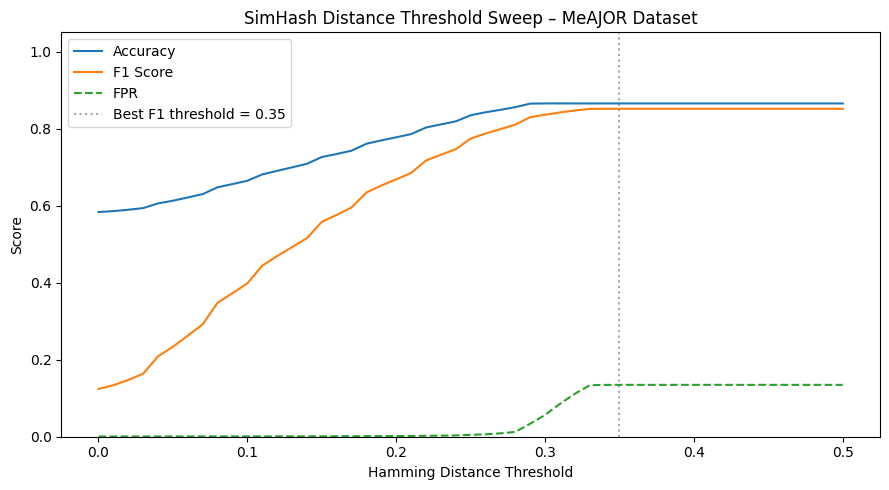

Threshold sweep plot saved.


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df["threshold"], thresh_df["acc"], label="Accuracy", marker="")
ax.plot(thresh_df["threshold"], thresh_df["f1"],  label="F1 Score",  marker="")
ax.plot(thresh_df["threshold"], thresh_df["fpr"], label="FPR",       marker="", linestyle="--")
ax.axvline(best_thresh_row["threshold"], color="grey", linestyle=":", alpha=0.7,
           label=f"Best F1 threshold = {best_thresh_row['threshold']}")
ax.set_xlabel("Hamming Distance Threshold")
ax.set_ylabel("Score")
ax.set_title("SimHash Distance Threshold Sweep – MeAJOR Dataset")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(results_dir / "meajor_simhash_threshold_sweep.png", dpi=150)
plt.show()
print("Threshold sweep plot saved.")

## 13. Confusion Matrix

Confusion matrix for the best kNN configuration on the held-out test set.

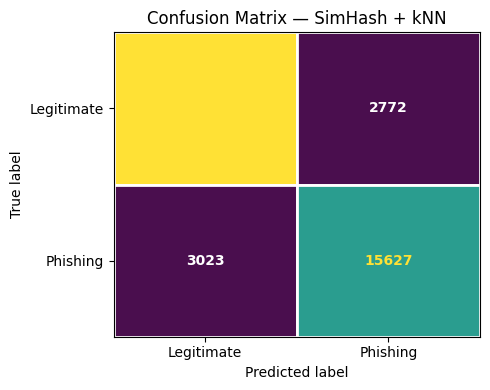

Confusion matrix saved.


In [17]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(test_labels, preds)

colors = np.array([['#FFE135', '#4A0E4E'],
                   ['#4A0E4E', '#2A9D8F']])

for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j, i), 1, 1, 
                                   facecolor=colors[i, j], 
                                   edgecolor='white', linewidth=2))
        
        text_color = '#FFE135' if colors[i, j] in ['#FFE135', '#2A9D8F'] else 'white'
        ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color=text_color)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Legitimate', 'Phishing'])
ax.set_yticklabels(['Legitimate', 'Phishing'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title("Confusion Matrix — SimHash + kNN")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(results_dir / "meajor_simhash_cm.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

## 14. Save Results

Final results are appended to the shared project results CSV for cross-model comparison.

In [14]:
results_csv = results_dir / "all_results.csv"

results_row = pd.DataFrame([final_results])

if results_csv.exists():
    existing = pd.read_csv(results_csv)
    # Remove any previous SimHash/MeAJOR row to avoid duplicates on re-run
    existing = existing[~((existing["Model"] == "SimHash + kNN") & (existing["Dataset"] == "MeAJOR"))]
    combined = pd.concat([existing, results_row], ignore_index=True)
else:
    combined = results_row

combined.to_csv(results_csv, index=False)
print("Results saved to all_results.csv")
print(results_row.to_string(index=False))

Results saved to all_results.csv
        Model Dataset  Accuracy  Precision  Recall     F1    FPR  Inference_ms       Config
SimHash + kNN  MeAJOR    0.8615     0.8493  0.8379 0.8436 0.1196        1.3408 128-bit, k=9
